# 01 — Portugal's public-debt interest burden

**Question.** How much interest does Portugal's general government pay, how has
that changed since 1995, and why did the euro amount and the share of GDP move
in different directions?

**Data.** `data/processed/portugal_debt_interest.csv`, written by the project
pipeline. The headline indicator is Eurostat ESA 2010 general-government
interest payable (`D41PAY`) over nominal GDP (`B1GQ`). It is *not*
central-government cash interest, *not* redemptions, and *not* the yield on
newly issued bonds.

**Scope.** Every statement below uses the harmonised ESA 2010 rows only
(1995 onward). The linked pre-1995 AMECO extension is loaded but held out, so
no lagged calculation ever straddles two accounting frameworks.

**To reproduce.** Processed data and figures are git-ignored, so run the
pipeline once before re-executing this notebook:

```bash
pt-debt all --config config/default.yaml
```

Notebook order: **01 headline** → [02 data quality](02_data_quality_and_provenance.ipynb)
→ [03 debt dynamics](03_debt_dynamics_and_decomposition.ipynb)
→ [04 pass-through and scenarios](04_rate_pass_through_and_scenarios.ipynb)
→ [05 European comparison](05_european_comparison.ipynb).

In [1]:
# Run correctly whether the kernel starts in notebooks/ or the repository root.
# Importing nbtools then puts src/ on the path, so pt_debt_interest is
# importable from a plain checkout without an editable install.
import sys
from pathlib import Path

_HERE = Path.cwd() if (Path.cwd() / "nbtools.py").is_file() else Path.cwd() / "notebooks"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

import nbtools as nb

nb.use_style()
ROOT = nb.repo_root()
nb.artefact_inventory(ROOT)

,artefact,path,present,size_kb
0,annual dataset,data/processed/portugal_debt_interest.csv,True,145.70
1,sqlite copy,data/processed/portugal_debt_interest.sqlite,True,184.00
2,comparator panel,data/processed/eurostat_panel_metrics.csv,True,"2,946.40"
3,burden decomposition,data/processed/interest_burden_decomposition.csv,True,7.40
4,validation report,reports/validation.json,True,2.90
5,source coverage,reports/source_coverage.csv,True,0.20
6,reproducibility metadata,reports/reproducibility.json,True,0.90
7,summary report,reports/summary.md,True,4.40
8,figure manifest,reports/figures/figures_manifest.csv,True,3.00


## Data vintage

Everything downstream depends on which download the dataset was built from, so
the vintage is stated before any number is interpreted.

In [3]:
raw = nb.load_dataset(ROOT)
df = nb.observed(nb.main_series(raw))

pd.Series(nb.dataset_vintage(raw), name="value").to_frame()

,value
rows,31
full_year_range,1995-2025
esa2010_year_range,1995-2025
sources,Eurostat
accounting_bases,ESA2010
earliest_retrieval_utc,20260728T200454Z
latest_retrieval_utc,20260728T200500Z


## The headline year

A single number is not a chart. The latest observed year is reported as a stat
block rather than a one-bar plot.

In [4]:
latest = df.iloc[-1]

headline = pd.DataFrame(
    [
        ("Interest paid", f"EUR {latest['interest_mio_eur'] / 1000:,.2f} bn"),
        ("Interest burden", nb.pct(latest["interest_pct_gdp"])),
        ("Gross debt", nb.pct(latest["debt_pct_gdp"])),
        ("Implicit interest rate", nb.pct(latest["implicit_interest_rate_average_debt_pct"], 2)),
        ("Ten-year market yield", nb.pct(latest["ten_year_yield_pct"], 2)),
        ("Primary balance", nb.pct(latest["primary_balance_pct_gdp"])),
        ("Overall balance", nb.pct(latest["overall_balance_pct_gdp"])),
        ("Total expenditure", nb.pct(latest["government_expenditure_pct_gdp"])),
        ("Total revenue", nb.pct(latest["government_revenue_pct_gdp"])),
        ("Observation status", str(latest["observation_status"])),
    ],
    columns=["indicator", f"{int(latest['year'])}"],
).set_index("indicator")
headline

,2025
indicator,
Interest paid,EUR 5.96 bn
Interest burden,1.9%
Gross debt,89.7%
Implicit interest rate,2.18%
Ten-year market yield,3.08%
Primary balance,2.6%
Overall balance,0.7%
Total expenditure,42.7%
Total revenue,43.4%


## 1. The burden through time

The interest burden is one series, so it gets one colour and no legend — the
title names it. Numbered bands mark the policy regimes configured in
`config/default.yaml`; the numbers are decoded in the table below. They are
descriptive labels, not estimated breaks.

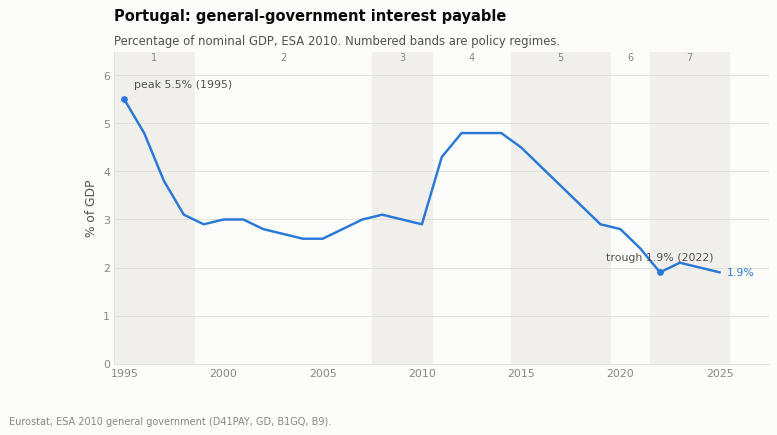

,band,first_year,last_year
regime,,,
Euro convergence,1,1995,1998
Early euro period,2,1999,2007
Global financial crisis,3,2008,2010
Sovereign-debt crisis and adjustment,4,2011,2014
ECB intervention and refinancing,5,2015,2019
Pandemic,6,2020,2021
Inflation and monetary tightening,7,2022,2025


In [5]:
peak = df.loc[df["interest_pct_gdp"].idxmax()]
trough = df.loc[df["interest_pct_gdp"].idxmin()]

fig, ax = nb.figure(height=4.6)
ax.plot(df["year"], df["interest_pct_gdp"], color=nb.SERIES[0])
ax.set_ylim(0, df["interest_pct_gdp"].max() * 1.18)
ax.set_xlim(df["year"].min() - 0.5, df["year"].max() + 2.5)
nb.shade_regimes(ax, df)

for row, tag in ((peak, "peak"), (trough, "trough")):
    ax.plot(row["year"], row["interest_pct_gdp"], "o", color=nb.SERIES[0], zorder=3)
    nb.annotate_point(
        ax,
        row["year"],
        row["interest_pct_gdp"],
        f"{tag} {row['interest_pct_gdp']:.1f}% ({int(row['year'])})",
    )

nb.label_last_point(
    ax,
    df["year"],
    df["interest_pct_gdp"],
    label="",
    color=nb.SERIES[0],
    fmt="{:.1f}%",
)
nb.finish(
    ax,
    title="Portugal: general-government interest payable",
    subtitle="Percentage of nominal GDP, ESA 2010. Numbered bands are policy regimes.",
    ylabel="% of GDP",
)
plt.show()

nb.regime_spans(df)

The shape is three episodes, not a trend: a steep convergence decline into the
euro, a doubling through the sovereign-debt crisis, and a long post-2014
descent that carried the burden below its pre-crisis level.

## 2. Euros and the GDP ratio move differently

Plotting a euro amount and a GDP share on two y-axes would invent a
relationship the data does not contain. They are shown as small multiples on
their own scales instead.

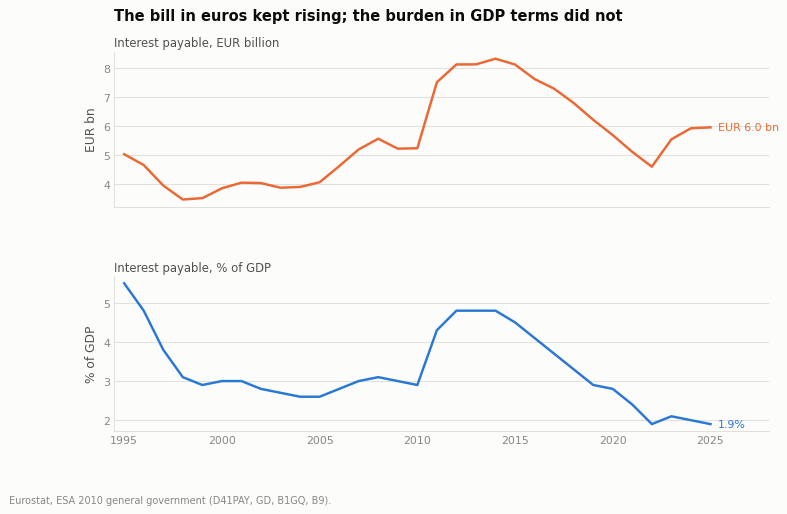

In [6]:
fig, axes = nb.figure(height=5.6, nrows=2, sharex=True)

axes[0].plot(df["year"], df["interest_mio_eur"] / 1000, color=nb.SERIES[1])
nb.label_last_point(
    axes[0],
    df["year"],
    df["interest_mio_eur"] / 1000,
    label="",
    color=nb.SERIES[1],
    fmt="EUR {:.1f} bn",
)
nb.finish(
    axes[0],
    title="The bill in euros kept rising; the burden in GDP terms did not",
    subtitle="Interest payable, EUR billion",
    ylabel="EUR bn",
    source="",
)

axes[1].plot(df["year"], df["interest_pct_gdp"], color=nb.SERIES[0])
nb.label_last_point(
    axes[1],
    df["year"],
    df["interest_pct_gdp"],
    label="",
    color=nb.SERIES[0],
    fmt="{:.1f}%",
)
nb.finish(
    axes[1],
    subtitle="Interest payable, % of GDP",
    ylabel="% of GDP",
)
for axis in axes:
    axis.set_xlim(df["year"].min() - 0.5, df["year"].max() + 3.0)
fig.subplots_adjust(hspace=0.45)
plt.show()

In [7]:
first, last = df.iloc[0], df.iloc[-1]
pd.DataFrame(
    {
        "interest (EUR bn)": [
            first["interest_mio_eur"] / 1000,
            last["interest_mio_eur"] / 1000,
        ],
        "interest (% GDP)": [first["interest_pct_gdp"], last["interest_pct_gdp"]],
        "nominal GDP (EUR bn)": [
            first["nominal_gdp_mio_eur"] / 1000,
            last["nominal_gdp_mio_eur"] / 1000,
        ],
        "debt (% GDP)": [first["debt_pct_gdp"], last["debt_pct_gdp"]],
    },
    index=[int(first["year"]), int(last["year"])],
).T

,1995,2025
interest (EUR bn),5.04,5.96
interest (% GDP),5.50,1.90
nominal GDP (EUR bn),91.02,306.75
debt (% GDP),62.20,89.70


## 3. Why the ratio fell while the bill grew

Indexing interest, the debt stock, and nominal GDP to a common base puts three
different magnitudes on **one** axis honestly. The gap that opens between the
GDP line and the interest line *is* the fall in the burden.

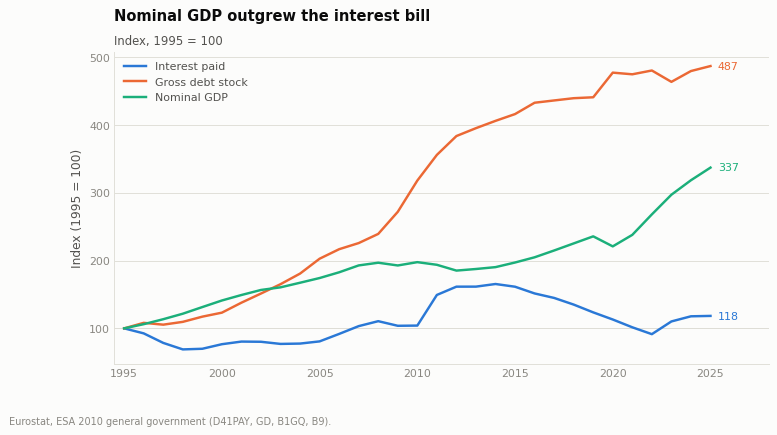

,Interest paid,Gross debt stock,Nominal GDP
year,,,
1995,100.00,100.00,100.00
2010,104.10,317.91,197.61
2014,165.40,405.93,190.28
2025,118.37,486.75,337.03


In [8]:
base_year = int(df["year"].iloc[0])
indexed = pd.DataFrame({"year": df["year"]})
components = {
    "Interest paid": "interest_mio_eur",
    "Gross debt stock": "debt_mio_eur",
    "Nominal GDP": "nominal_gdp_mio_eur",
}
for label, column in components.items():
    indexed[label] = df[column] / df[column].iloc[0] * 100.0

fig, ax = nb.figure(height=4.6)
for position, label in enumerate(components):
    ax.plot(indexed["year"], indexed[label], color=nb.SERIES[position], label=label)
    nb.label_last_point(
        ax,
        indexed["year"],
        indexed[label],
        label="",
        color=nb.SERIES[position],
        fmt="{:.0f}",
    )
ax.axhline(100, color=nb.MUTED, linewidth=0.8, zorder=0)
ax.legend(loc="upper left")
ax.set_xlim(df["year"].min() - 0.5, df["year"].max() + 3.0)
nb.finish(
    ax,
    title="Nominal GDP outgrew the interest bill",
    subtitle=f"Index, {base_year} = 100",
    ylabel=f"Index ({base_year} = 100)",
)
plt.show()

indexed.set_index("year").loc[[base_year, 2010, 2014, int(df["year"].iloc[-1])]]

## 4. Turning points

Largest single-year moves in the burden, in both directions. These locate the
episodes; notebook 03 attributes them to the effective rate, the debt ratio, and
nominal growth.

In [9]:
moves = df[["year", "interest_pct_gdp"]].copy()
moves["change_pp"] = moves["interest_pct_gdp"].diff()
moves = moves.dropna(subset=["change_pp"])

turning_points = pd.concat(
    [
        moves.nlargest(5, "change_pp").assign(direction="largest increases"),
        moves.nsmallest(5, "change_pp").assign(direction="largest decreases"),
    ]
)
turning_points["year"] = turning_points["year"].astype(int)
turning_points.set_index(["direction", "year"])[["interest_pct_gdp", "change_pp"]]

interest_pct_gdp  change_pp
direction         year                             
largest increases 2011              4.30       1.40
                  2012              4.80       0.50
                  2007              3.00       0.20
                  2023              2.10       0.20
                  2006              2.80       0.20
largest decreases 1997              3.80      -1.00
                  1996              4.80      -0.70
                  1998              3.10      -0.70
                  2022              1.90      -0.50
                  2016              4.10      -0.40

## 5. Regime averages

Regime labels come from `config/default.yaml`. They are hypotheses about
periodisation, so the table reports dispersion alongside the mean rather than
implying each regime is a single state.

In [10]:
statistics = df.groupby("regime").agg(
    years=("year", "size"),
    interest_pct_gdp_mean=("interest_pct_gdp", "mean"),
    interest_pct_gdp_sd=("interest_pct_gdp", "std"),
    debt_pct_gdp_mean=("debt_pct_gdp", "mean"),
    implicit_rate_mean=("implicit_interest_rate_average_debt_pct", "mean"),
    primary_balance_mean=("primary_balance_pct_gdp", "mean"),
)
regimes = nb.regime_spans(df).join(statistics)
regimes

,band,first_year,last_year,years,interest_pct_gdp_mean,interest_pct_gdp_sd,debt_pct_gdp_mean,implicit_rate_mean,primary_balance_mean
regime,,,,,,,,,
Euro convergence,1,1995,1998,4,4.30,1.06,59.95,6.74,-0.20
Early euro period,2,1999,2007,9,2.82,0.16,64.07,4.64,-1.54
Global financial crisis,3,2008,2010,3,3.00,0.10,87.67,3.67,-5.37
Sovereign-debt crisis and adjustment,4,2011,2014,4,4.67,0.25,126.47,3.81,-1.95
ECB intervention and refinancing,5,2015,2019,5,3.70,0.63,125.08,2.98,1.76
Pandemic,6,2020,2021,2,2.60,0.28,129.00,2.05,-1.70
Inflation and monetary tightening,7,2022,2025,4,1.98,0.10,97.83,2.05,2.50


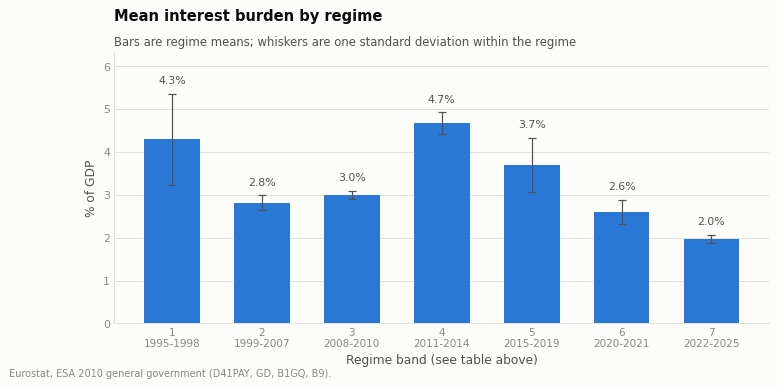

In [11]:
fig, ax = nb.figure(height=4.0)
positions = range(len(regimes))
ax.bar(
    list(positions),
    regimes["interest_pct_gdp_mean"],
    color=nb.SERIES[0],
    width=0.62,
)
ax.errorbar(
    list(positions),
    regimes["interest_pct_gdp_mean"],
    yerr=regimes["interest_pct_gdp_sd"].fillna(0.0),
    fmt="none",
    ecolor=nb.SUBTLE,
    elinewidth=1.0,
    capsize=3,
)
spread = regimes["interest_pct_gdp_sd"].fillna(0.0)
for position, value, deviation in zip(
    positions, regimes["interest_pct_gdp_mean"], spread, strict=True
):
    ax.annotate(
        f"{value:.1f}%",
        xy=(position, value + deviation),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=nb.SUBTLE,
    )
ax.set_xticks(list(positions))
ax.set_xticklabels(
    [
        f"{band}\n{first}-{last}"
        for band, first, last in zip(
            regimes["band"], regimes["first_year"], regimes["last_year"], strict=True
        )
    ],
    fontsize=8.5,
)
ax.set_ylim(0, (regimes["interest_pct_gdp_mean"] + spread).max() * 1.18)
nb.finish(
    ax,
    title="Mean interest burden by regime",
    subtitle="Bars are regime means; whiskers are one standard deviation within the regime",
    ylabel="% of GDP",
    xlabel="Regime band (see table above)",
)
plt.show()

## 6. Interest against the rest of the budget

Percent of GDP is the right denominator for comparing across countries and
across time. It is not the denominator a finance ministry works in. Interest as
a share of *total government expenditure* answers a different and more concrete
question: how much of what the state spends buys nothing current.

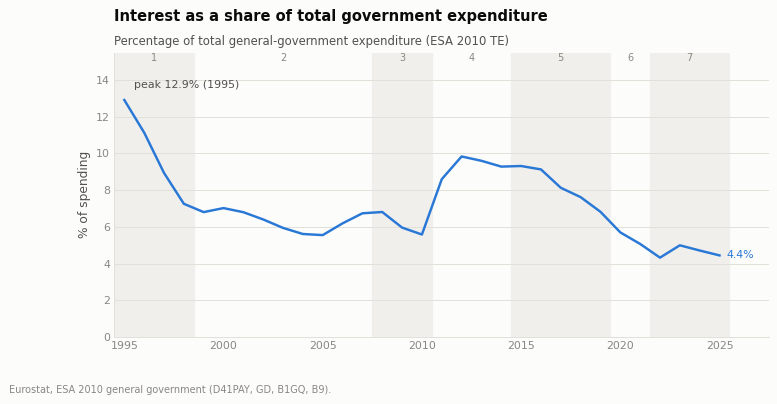

In [12]:
budget = df.dropna(subset=["government_expenditure_pct_gdp"]).copy()
budget["interest_share_of_spending_pct"] = (
    budget["interest_pct_gdp"] / budget["government_expenditure_pct_gdp"] * 100.0
)

fig, ax = nb.figure(height=4.2)
ax.plot(
    budget["year"],
    budget["interest_share_of_spending_pct"],
    color=nb.SERIES[0],
)
ax.set_ylim(0, budget["interest_share_of_spending_pct"].max() * 1.20)
ax.set_xlim(budget["year"].min() - 0.5, budget["year"].max() + 2.5)
nb.shade_regimes(ax, budget)
peak_share = budget.loc[budget["interest_share_of_spending_pct"].idxmax()]
nb.annotate_point(
    ax,
    peak_share["year"],
    peak_share["interest_share_of_spending_pct"],
    f"peak {peak_share['interest_share_of_spending_pct']:.1f}% ({int(peak_share['year'])})",
)
nb.label_last_point(
    ax,
    budget["year"],
    budget["interest_share_of_spending_pct"],
    label="",
    color=nb.SERIES[0],
    fmt="{:.1f}%",
)
nb.finish(
    ax,
    title="Interest as a share of total government expenditure",
    subtitle="Percentage of total general-government expenditure (ESA 2010 TE)",
    ylabel="% of spending",
)
plt.show()

In [13]:
budget_view = budget.set_index("year")[
    [
        "government_revenue_pct_gdp",
        "government_expenditure_pct_gdp",
        "interest_pct_gdp",
        "interest_share_of_spending_pct",
        "overall_balance_pct_gdp",
    ]
]
milestones = [1995, 2012, 2020, int(budget["year"].iloc[-1])]
budget_view.loc[[year for year in milestones if year in budget_view.index]]

,government_revenue_pct_gdp,government_expenditure_pct_gdp,interest_pct_gdp,interest_share_of_spending_pct,overall_balance_pct_gdp
year,,,,,
1995,37.40,42.60,5.50,12.91,-5.20
2012,42.60,48.80,4.80,9.84,-6.20
2020,43.40,49.10,2.80,5.70,-5.80
2025,43.40,42.70,1.90,4.45,0.70


## 7. Cumulative cost

Summing the annual bills gives the scale of the transfer; expressing it against
the latest year's GDP gives it a unit a reader can hold. This is a scale
comparison, not a claim that the money was available to spend elsewhere — a
lower debt path would have implied different financing conditions.

In [14]:
cumulative_bn = df["interest_mio_eur"].sum() / 1000
latest_gdp_bn = df["nominal_gdp_mio_eur"].iloc[-1] / 1000

pd.Series(
    {
        "period": f"{int(df['year'].iloc[0])}-{int(df['year'].iloc[-1])}",
        "cumulative interest (EUR bn)": round(cumulative_bn, 1),
        "latest nominal GDP (EUR bn)": round(latest_gdp_bn, 1),
        "cumulative interest / latest GDP": f"{cumulative_bn / latest_gdp_bn:.2f}x",
        "mean annual burden (% GDP)": round(df["interest_pct_gdp"].mean(), 2),
    },
    name="value",
).to_frame()

,value
period,1995-2025
cumulative interest (EUR bn),171.50
latest nominal GDP (EUR bn),306.70
cumulative interest / latest GDP,0.56x
mean annual burden (% GDP),3.29


## What the data shows

The summary below is generated from the loaded dataset, so it cannot drift out
of step with the figures above when the pipeline is re-run.

In [15]:
start, end = df.iloc[0], df.iloc[-1]
crisis = df.loc[df["year"].between(2011, 2014)]

print(f"Period covered            : {int(start['year'])}-{int(end['year'])}")
print(
    f"Burden, first to last     : {start['interest_pct_gdp']:.1f}% -> "
    f"{end['interest_pct_gdp']:.1f}% of GDP "
    f"({end['interest_pct_gdp'] - start['interest_pct_gdp']:+.1f} pp)"
)
print(
    f"Euro bill, first to last  : EUR {start['interest_mio_eur'] / 1000:.2f} bn -> "
    f"EUR {end['interest_mio_eur'] / 1000:.2f} bn "
    f"({end['interest_mio_eur'] / start['interest_mio_eur'] - 1:+.1%})"
)
print(
    f"Crisis plateau 2011-2014  : {crisis['interest_pct_gdp'].mean():.1f}% of GDP "
    f"on debt averaging {crisis['debt_pct_gdp'].mean():.0f}% of GDP"
)
effective_rate = df["implicit_interest_rate_average_debt_pct"].dropna()
print(
    f"Effective rate, first-obs : {effective_rate.iloc[0]:.2f}% -> {effective_rate.iloc[-1]:.2f}%"
)
print(
    f"Debt ratio, peak to last  : {df['debt_pct_gdp'].max():.1f}% "
    f"({int(df.loc[df['debt_pct_gdp'].idxmax(), 'year'])}) -> "
    f"{end['debt_pct_gdp']:.1f}%"
)

Period covered            : 1995-2025
Burden, first to last     : 5.5% -> 1.9% of GDP (-3.6 pp)
Euro bill, first to last  : EUR 5.04 bn -> EUR 5.96 bn (+18.4%)
Crisis plateau 2011-2014  : 4.7% of GDP on debt averaging 126% of GDP
Effective rate, first-obs : 7.93% -> 2.18%
Debt ratio, peak to last  : 134.1% (2020) -> 89.7%


**Reading.** The euro bill in the latest year is larger than in the first, while
the burden relative to GDP is roughly a third of its 1995 level. Two things did
that work: the effective interest rate on the outstanding stock fell by more
than half, and nominal GDP grew faster than the debt stock over the period as a
whole. Notebook 03 separates those two channels; notebook 04 asks how quickly a
change in market rates reaches the effective rate.

**Caveat.** The last observations carry Eurostat provisional flags. Notebook 02
lists which series are flagged and where the official and calculated ratios
disagree.